<a href="https://colab.research.google.com/github/Matheusbcy/-Data-Science-IA-/blob/main/Deep%20Learning/Boltzmann%20Machines/Boltzmann_Machine_redu%C3%A7%C3%A3o_de_dimensionalidade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning - Boltzmann Machines - Redução de dimensionalidade

In [1]:
import numpy as np
import matplotlib
import sklearn

In [2]:
import matplotlib.pyplot as plt
from sklearn import datasets, metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [3]:
from sklearn.neural_network import BernoulliRBM
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline

In [ ]:
base = datasets.load_digits()
base

In [5]:
X = np.asarray(base.data, "float32")

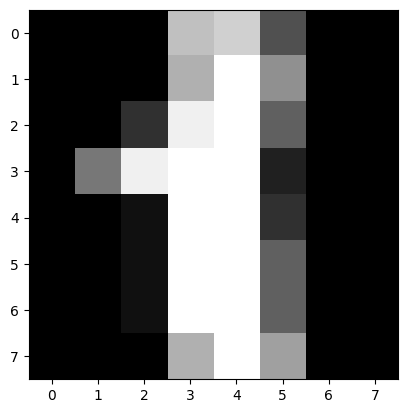

In [15]:
plt.imshow(X[1].reshape((8,8)), cmap = "gray")

In [16]:
y = base.target

In [18]:
normalizador = MinMaxScaler(feature_range = (0,1))

In [19]:
X = normalizador . fit_transform(X)

In [21]:
X_treinamento, X_teste, y_treinamento, y_teste = train_test_split(X, y, test_size = 0.2, random_state= 42)

In [22]:
X_treinamento.shape, X_teste.shape

((1437, 64), (360, 64))

In [23]:
y_treinamento.shape, y_teste.shape

((1437,), (360,))

In [24]:
rbm = BernoulliRBM(random_state = 0)
rbm.n_iter = 25
rbm.n_components = 50
naive_rbm = GaussianNB()
classificador_rbm = Pipeline(steps = [("rbm", rbm), ("naive", naive_rbm)])
classificador_rbm.fit(X_treinamento, y_treinamento)

Pipeline(steps=[('rbm',
                 BernoulliRBM(n_components=50, n_iter=25, random_state=0)),
                ('naive', GaussianNB())])

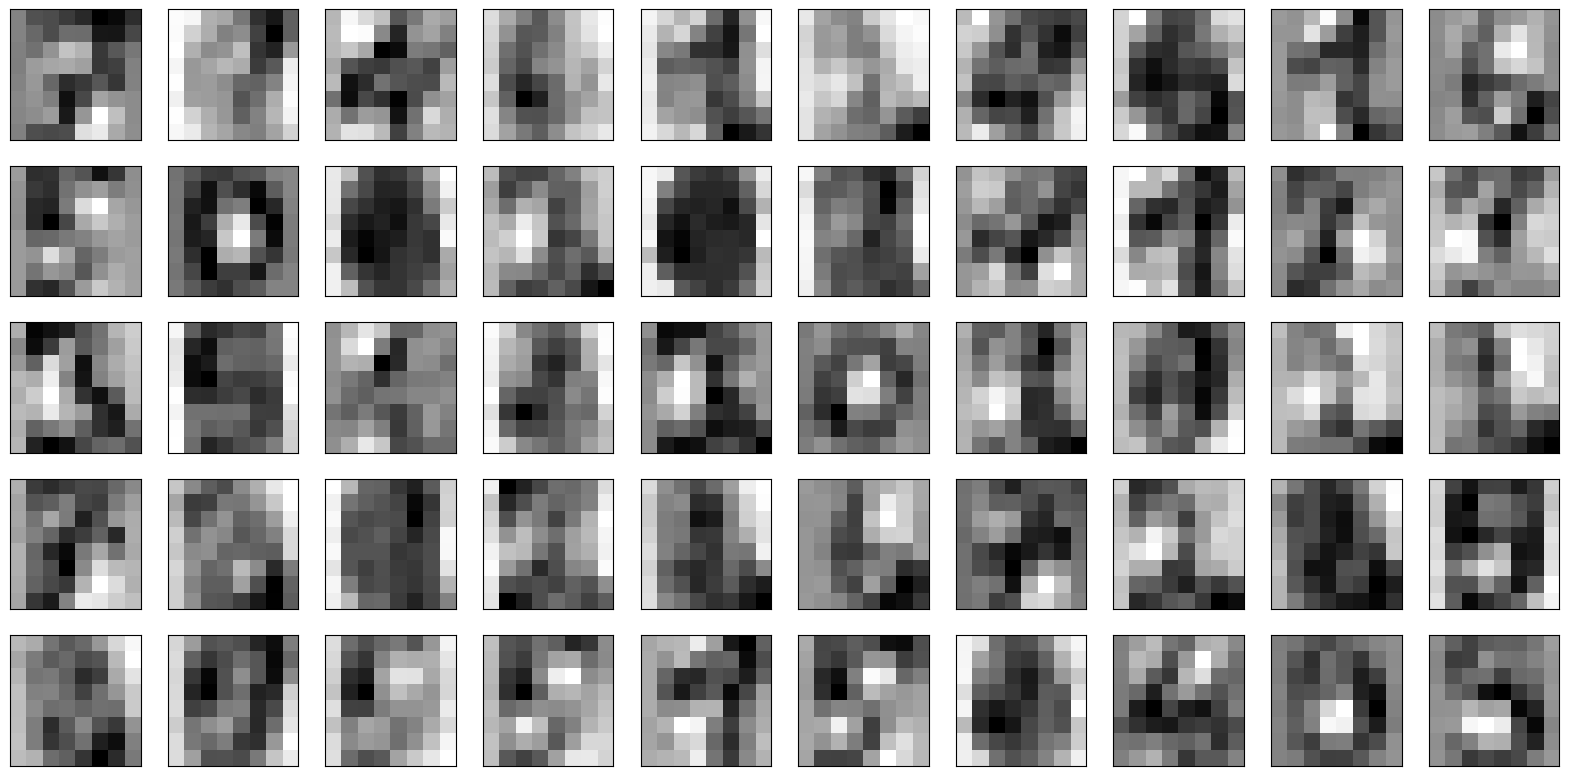

In [28]:
plt.figure(figsize = (20, 20))
for i, componente in enumerate(rbm.components_):
  plt.subplot(10, 10, i + 1)
  plt.imshow(componente.reshape((8, 8)), cmap = plt.cm.gray_r)
  plt.xticks(())
  plt.yticks(())

# COM RBM

In [ ]:
previsoes_rbm = classificador_rbm.predict(X_teste)

In [33]:
metrics.accuracy_score(y_teste, previsoes_rbm)

0.8972222222222223

# SEM RBM

In [39]:
naive_simples = GaussianNB()
naive_simples.fit(X_treinamento, y_treinamento)
previsoes_simples = naive_simples.predict(X_teste)

In [41]:
metrics.accuracy_score(y_teste, previsoes_simples)

0.8333333333333334

# Exercicio - RBM com Redes Neurais Densas

In [42]:
from sklearn.neural_network import MLPClassifier

In [44]:
rbm = BernoulliRBM(random_state = 0)
rbm.n_iter = 25
rbm.n_components = 50
clf = MLPClassifier(random_state=1, max_iter=300)
classificador_rbm = Pipeline(steps = [("rbm", rbm), ("clf", clf)])
classificador_rbm.fit(X_treinamento, y_treinamento)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Pipeline(steps=[('rbm',
                 BernoulliRBM(n_components=50, n_iter=25, random_state=0)),
                ('clf', MLPClassifier(max_iter=300, random_state=1))])

# COM RBM E REDES NEURAIS

In [45]:
previsoes_clf = classificador_rbm.predict(X_teste)

In [47]:
metrics.accuracy_score(y_teste, previsoes_clf)

0.9444444444444444